Mounted at /content/drive
Training images: 6458 | Validation images: 1614

Train Set 'check_corners' distribution (1 = Tag, 0 = No Tag):
check_corners
1    6458
Name: count, dtype: int64


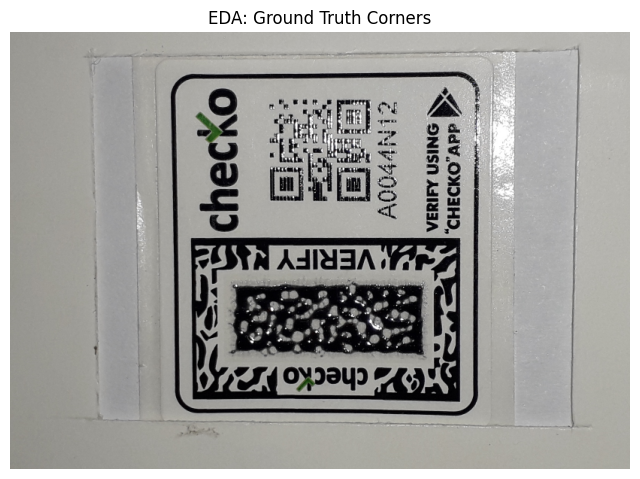

In [1]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Assignment'
image_folder = os.path.join(base_path, 'flash_images', 'flash_images')
train_csv_path = os.path.join(base_path, 'train_corners.csv')
val_csv_path = os.path.join(base_path, 'val_corners.csv')

df_train = pd.read_csv(train_csv_path)
df_val = pd.read_csv(val_csv_path)

print(f"Training images: {len(df_train)} | Validation images: {len(df_val)}")

print("\nTrain Set 'check_corners' distribution (1 = Tag, 0 = No Tag):")
print(df_train['check_corners'].value_counts())

sample = df_train[df_train['check_corners'] == 1].iloc[0]
img_path = os.path.join(image_folder, sample['filename'])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

coords_str = str(sample['corners']).split()
coords = np.array([float(x) for x in coords_str]).reshape(4, 2)

plt.figure(figsize=(8, 6))
plt.imshow(img)
cv2.polylines(img, [np.int32(coords)], isClosed=True, color=(0, 255, 0), thickness=5)
for point in coords:
    cv2.circle(img, tuple(np.int32(point)), radius=8, color=(255, 0, 0), thickness=-1)
plt.title("EDA: Ground Truth Corners")
plt.axis("off")
plt.show()

In [2]:
# Dataloader Cell

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import pandas as pd
import numpy as np

class TagDataset(Dataset):
    def __init__(self, dataframe, image_dir, image_size=224):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = os.path.join(self.image_dir, row['filename'])

        try:
            image = Image.open(img_name).convert("RGB")
        except:
            image = Image.new('RGB', (self.image_size, self.image_size))

        orig_w, orig_h = image.size
        image = self.transform(image)

        presence = float(row['check_corners'])

        corners = np.zeros(8, dtype=np.float32)
        if presence == 1.0 and pd.notna(row['corners']):
            coords_str = str(row['corners']).split()
            coords_float = [float(x) for x in coords_str]

            for i in range(4):
                corners[i*2] = coords_float[i*2] / orig_w
                corners[i*2 + 1] = coords_float[i*2 + 1] / orig_h

        return image, torch.tensor([presence], dtype=torch.float32), torch.tensor(corners, dtype=torch.float32)

train_dataset = TagDataset(df_train, image_folder)
val_dataset = TagDataset(df_val, image_folder)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)

print(f"Train batches: {len(train_loader)}")

Train batches: 51


In [3]:
# Loading the model on hardware

import torch.nn as nn
import torchvision.models as models

class TagDetector(nn.Module):
    def __init__(self):
        super(TagDetector, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        num_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Identity()

        self.presence_head = nn.Linear(num_features, 1)

        self.regression_head = nn.Linear(num_features, 8)

    def forward(self, x):
        features = self.backbone(x)

        presence_logits = self.presence_head(features)
        corners = self.regression_head(features)

        return presence_logits, corners

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TagDetector().to(device)
print(f"Model loaded on: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


Model loaded on: cuda


In [4]:
# Training cell
import torch.optim as optim
import torch.amp

optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion_presence = nn.BCEWithLogitsLoss()
criterion_corners = nn.MSELoss(reduction='none')

epochs = 20
best_val_loss = float('inf')
save_path = '/content/best_tag_detector.pth'

scaler = torch.amp.GradScaler('cuda')

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for images, presence_labels, true_corners in train_loader:
        images = images.to(device, non_blocking=True)
        presence_labels = presence_labels.to(device, non_blocking=True)
        true_corners = true_corners.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred_presence, pred_corners = model(images)

            loss_presence = criterion_presence(pred_presence, presence_labels)
            loss_corners_all = criterion_corners(pred_corners, true_corners)
            loss_corners_per_image = loss_corners_all.mean(dim=1).unsqueeze(1)
            loss_corners = (loss_corners_per_image * presence_labels).sum() / (presence_labels.sum() + 1e-8)

            loss = loss_presence + (loss_corners * 10)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for images, presence_labels, true_corners in val_loader:
            images = images.to(device, non_blocking=True)
            presence_labels = presence_labels.to(device, non_blocking=True)
            true_corners = true_corners.to(device, non_blocking=True)


            with torch.amp.autocast('cuda'):
                pred_presence, pred_corners = model(images)

                loss_presence = criterion_presence(pred_presence, presence_labels)
                loss_corners_all = criterion_corners(pred_corners, true_corners)
                loss_corners_per_image = loss_corners_all.mean(dim=1).unsqueeze(1)
                loss_corners = (loss_corners_per_image * presence_labels).sum() / (presence_labels.sum() + 1e-8)

                loss = loss_presence + (loss_corners * 10)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        print(f"   => Val loss decreased ({best_val_loss:.4f} --> {avg_val_loss:.4f}). Saving model...")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)

Epoch [1/20] - Train Loss: 3.5766 | Val Loss: 0.2018
   => Val loss decreased (inf --> 0.2018). Saving model...
Epoch [2/20] - Train Loss: 0.1849 | Val Loss: 0.1264
   => Val loss decreased (0.2018 --> 0.1264). Saving model...
Epoch [3/20] - Train Loss: 0.1838 | Val Loss: 0.0893
   => Val loss decreased (0.1264 --> 0.0893). Saving model...
Epoch [4/20] - Train Loss: 0.1009 | Val Loss: 0.0853
   => Val loss decreased (0.0893 --> 0.0853). Saving model...
Epoch [5/20] - Train Loss: 0.0839 | Val Loss: 0.0879
Epoch [6/20] - Train Loss: 0.0806 | Val Loss: 0.0725
   => Val loss decreased (0.0853 --> 0.0725). Saving model...
Epoch [7/20] - Train Loss: 0.0734 | Val Loss: 0.0677
   => Val loss decreased (0.0725 --> 0.0677). Saving model...
Epoch [8/20] - Train Loss: 0.0707 | Val Loss: 0.0775
Epoch [9/20] - Train Loss: 0.0938 | Val Loss: 0.0770
Epoch [10/20] - Train Loss: 0.0892 | Val Loss: 0.0705
Epoch [11/20] - Train Loss: 0.0789 | Val Loss: 0.0759
Epoch [12/20] - Train Loss: 0.0726 | Val Loss:

Best weights loaded successfully!

Testing on random Validation samples...


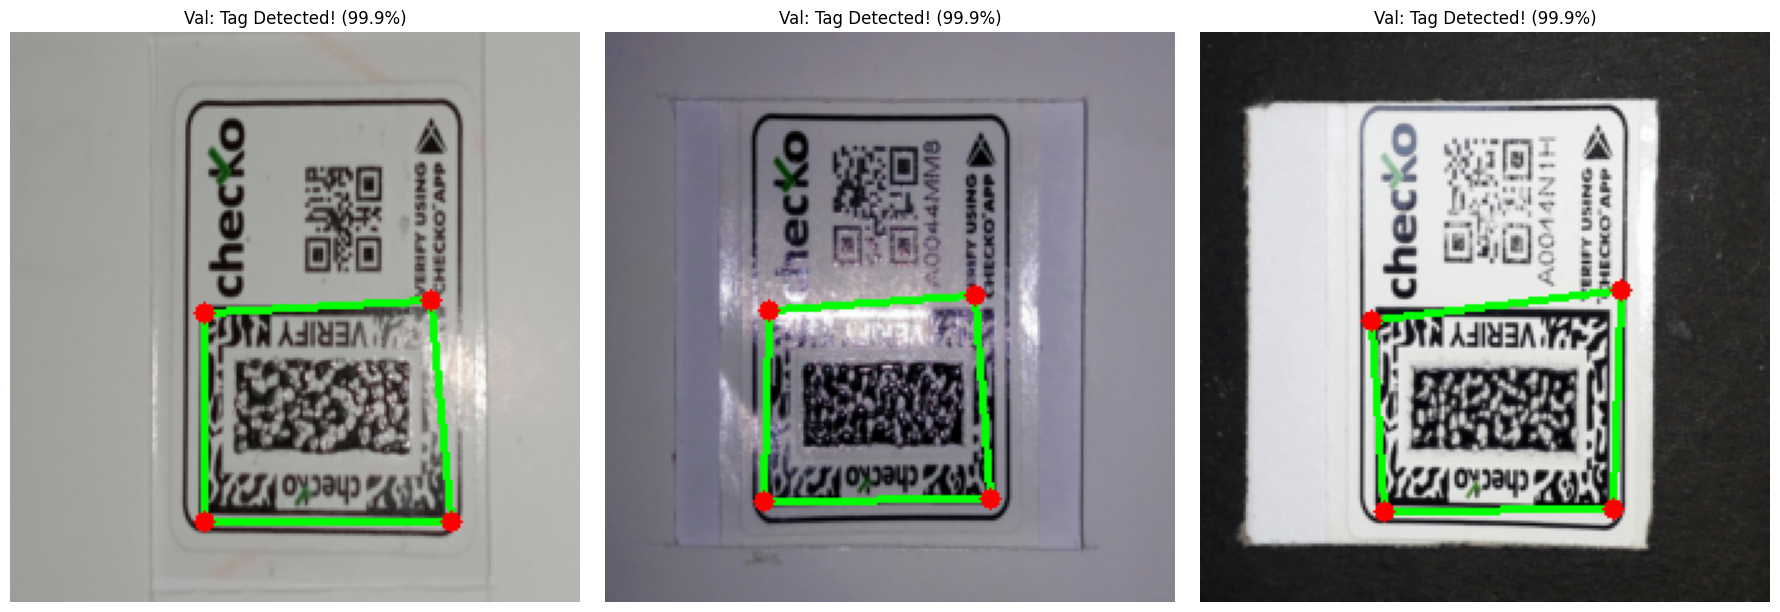

Testing on random Training samples...


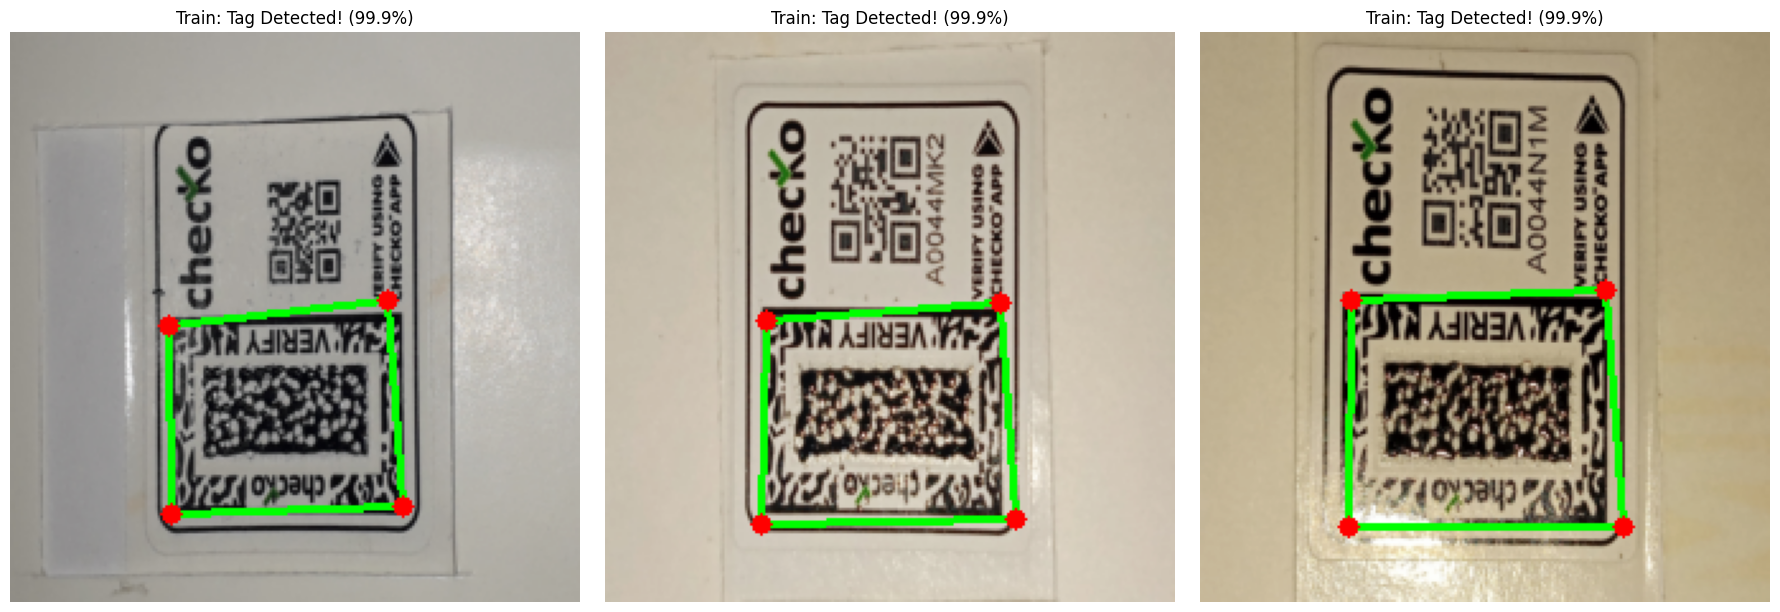

In [11]:
# Test
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2
import random

model.load_state_dict(torch.load(save_path))
model.eval()
print("Best weights loaded successfully!\n")

def test_random_samples(dataset, model, num_images=3, title_prefix="Dataset"):
    fig, axes = plt.subplots(1, num_images, figsize=(18, 6))

    random_indices = random.sample(range(len(dataset)), num_images)

    images = []
    for idx in random_indices:
        img, _, _ = dataset[idx]
        images.append(img)

    image_batch = torch.stack(images).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred_presence, pred_corners = model(image_batch)
            pred_probs = torch.sigmoid(pred_presence).cpu().numpy()
            pred_corners = pred_corners.cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(num_images):
        img_tensor = image_batch[i].cpu()

        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        img_draw = (img_np * 255).astype(np.uint8).copy()

        prob = pred_probs[i][0]

        if prob > 0.5:
            corners = pred_corners[i].reshape(4, 2) * 224

            cv2.polylines(img_draw, [np.int32(corners)], isClosed=True, color=(0, 255, 0), thickness=2)
            for point in corners:
                cv2.circle(img_draw, tuple(np.int32(point)), radius=4, color=(255, 0, 0), thickness=-1)

            title = f"{title_prefix}: Tag Detected! ({prob*100:.1f}%)"
        else:
            title = f"{title_prefix}: No Tag ({prob*100:.1f}%)"

        axes[i].imshow(img_draw)
        axes[i].set_title(title)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

print("Testing on random Validation samples...")
test_random_samples(val_dataset, model, num_images=3, title_prefix="Val")

print("Testing on random Training samples...")
test_random_samples(train_dataset, model, num_images=3, title_prefix="Train")